# TF2 FinOps Watch — EDA & Data Understanding

**Author:** AIOps Team (hao-aiops)  
**Dataset period:** 2026-03-01 → 2026-05-31 (92 ngày)  
**Goal:** Hiểu rõ cấu trúc, phân phối, seasonality, và dấu hiệu anomaly trong cost data trước khi chọn model.

---

## 0. Giới thiệu & Lưu ý quan trọng về Dataset

### Bối cảnh
Dataset này mô phỏng AWS cost data của một công ty mid-size với **6 linked accounts**, baseline ~$180k/tháng. Dữ liệu bao gồm:

| File | Mô tả |
|---|---|
| `cur_line_items.csv` | CUR 2.0 resource-level daily — nguồn chi tiết nhất (24,533 rows) |
| `cost_explorer_daily.csv` | Aggregate daily theo account × service (2,770 rows) |
| `anomaly_labels_public.csv` | **Chỉ 2 anomaly mẫu + 1 benign mẫu** — phần còn lại mentor giữ |
| `metrics_haikhoa/*.csv` | CloudWatch-style metrics (CPU, memory, network...) per resource |

### Về Labels — ĐỌC KỸ TRƯỚC KHI CODE

> ⚠️ **`anomaly_labels_public.csv` chỉ chứa 3 nhãn mẫu** (A2, A6, B2). Đây là *calibration set*, KHÔNG phải toàn bộ ground truth.  
> Ground truth đầy đủ (7 anomaly groups + 3 benign traps) do **mentor giữ** và chỉ dùng để chấm cuối kỳ.  
> → **Không được dùng label này để train supervised classifier trực tiếp** — sẽ bị label leak + overfit trên test set.  
> → Chiến lược đúng: **unsupervised/semi-supervised detection** trên cost signal, dùng 3 nhãn mẫu để *calibrate threshold*, không train.

### Các anomaly type cần detect

| Type | Tín hiệu |
|---|---|
| `runaway_usage` | Compute mới, chạy 24/7, không giảm cuối tuần |
| `idle_resource` | Cost đều đặn, usage rất thấp, kéo dài |
| `untagged_spend` | `resource_tags_user_team` trống, cost lớn |
| `sudden_spike` | Cost nhảy bậc thang ngắn ngày |
| `gradual_drift` | Trend tăng chậm nhiều tuần |

### Bẫy False Positive (quan trọng để đạt FP ≤10%)
Dataset cố ý chứa **benign events** trông y hệt anomaly: flash-sale, migration 1 lần, load test định kỳ.  
Detector ngây thơ `cost_tăng → alert` sẽ **fail FP target**.  
B2 (migration egress ~$650/day, 3 ngày) là ví dụ mẫu.

### Về metrics_haikhoa
Các file metrics (EC2, RDS, SageMaker, DynamoDB, Other) chứa CloudWatch-style per-resource metrics với **label column** đầy đủ hơn — đây là **nguồn bổ sung** có thể dùng làm feature engineering hoặc semi-supervised learning.

**Cột đặc biệt:**
- `cpu_h0..cpu_h23` — hourly CPU profile trong ngày (24 giá trị), cho phép phân tích **intra-day pattern** (flat 24/7 = runaway signal)
- `gpu_utilization` — chỉ có trong EC2 và SageMaker metrics
- `database_connections` — chỉ có trong RDS metrics (~0 = idle signal)

### Lưu ý khi xử lý data
- CUR `is_estimated=True` ở 2 ngày cuối → xử lý riêng khi inference
- `resource_tags_user_owner` có ~99.6% null — by design, không phải data quality issue
- Join CUR và CE cần dùng `service_code` (CUR) ↔ `service_code` (CE), không dùng tên service (khác nhau)
- Time series: KHÔNG shuffle, phải giữ tính liên tục để split train/test

In [1]:
## 1. Setup & Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('tab10')

DATA_DIR = Path('../../data')
METRICS_DIR = DATA_DIR / 'metrics_haikhoa'

# Load CUR
cur = pd.read_csv(DATA_DIR / 'cur_line_items.csv',
                  parse_dates=['line_item_usage_start_date', 'line_item_usage_end_date'])
cur['date'] = cur['line_item_usage_start_date'].dt.normalize()

# Load Cost Explorer daily
ce = pd.read_csv(DATA_DIR / 'cost_explorer_daily.csv', parse_dates=['date'])

# Load labels
labels = pd.read_csv(DATA_DIR / 'anomaly_labels_public.csv', parse_dates=['start_date', 'end_date'])

# Load metrics
ec2_m   = pd.read_csv(METRICS_DIR / 'ec2_metrics.csv',            parse_dates=['timestamp'])
rds_m   = pd.read_csv(METRICS_DIR / 'rds_metrics.csv',            parse_dates=['timestamp'])
sm_m    = pd.read_csv(METRICS_DIR / 'sagemaker_metrics.csv',      parse_dates=['timestamp'])
ddb_m   = pd.read_csv(METRICS_DIR / 'ddb_metrics.csv',            parse_dates=['timestamp'])
other_m = pd.read_csv(METRICS_DIR / 'other_services_metrics.csv', parse_dates=['timestamp'])

print(f'CUR shape:        {cur.shape}')
print(f'CE shape:         {ce.shape}')
print(f'Labels (public):  {labels.shape}')
print(f'EC2 metrics:      {ec2_m.shape}')
print(f'RDS metrics:      {rds_m.shape}')
print(f'SageMaker:        {sm_m.shape}')
print(f'DynamoDB:         {ddb_m.shape}')
print(f'Other services:   {other_m.shape}')

CUR shape:        (24533, 24)
CE shape:         (2770, 8)
Labels (public):  (3, 12)
EC2 metrics:      (10308, 33)
RDS metrics:      (1545, 33)
SageMaker:        (1104, 33)
DynamoDB:         (245, 32)
Other services:   (11331, 32)


In [2]:
## 2. Tổng quan Dataset — Schema & Thống kê cơ bản

print('=== CUR columns ===');
print(list(cur.columns))
print()

# Summary statistics for cost
print('=== CUR cost stats ===')
print(cur['line_item_unblended_cost'].describe())
print(f'Total spend: ${cur["line_item_unblended_cost"].sum():,.2f}')
print()

# Date range
print(f'Date range: {cur.date.min().date()} → {cur.date.max().date()}')
print(f'Unique dates: {cur.date.nunique()} days')
print(f'Unique resources: {cur["line_item_resource_id"].nunique()}')
print(f'Unique accounts: {cur["line_item_usage_account_name"].nunique()}')
print(f'Unique services: {cur["line_item_product_code"].nunique()}')

# Missing values analysis
print('\n=== Missing Values (CUR) ===')
missing = cur.isnull().sum()
missing_pct = (missing / len(cur) * 100).round(1)
mv_df = pd.DataFrame({'missing_count': missing, 'pct': missing_pct})
print(mv_df[mv_df.missing_count > 0].sort_values('pct', ascending=False))

print()
print('=== Tag completeness ===')
tag_cols = [c for c in cur.columns if 'resource_tags' in c]
for col in tag_cols:
    n_missing = cur[col].isna().sum() + (cur[col] == '').sum()
    print(f'  {col}: {n_missing}/{len(cur)} missing ({n_missing/len(cur)*100:.1f}%)')

=== CUR columns ===
['bill_billing_period_start_date', 'bill_payer_account_id', 'line_item_usage_account_id', 'line_item_usage_account_name', 'line_item_line_item_type', 'line_item_usage_start_date', 'line_item_usage_end_date', 'line_item_product_code', 'line_item_usage_type', 'line_item_operation', 'line_item_resource_id', 'line_item_usage_amount', 'pricing_unit', 'line_item_unblended_rate', 'line_item_unblended_cost', 'line_item_currency_code', 'product_product_name', 'product_region_code', 'product_instance_type', 'resource_tags_user_team', 'resource_tags_user_environment', 'resource_tags_user_cost_center', 'resource_tags_user_owner', 'date']

=== CUR cost stats ===
count    24533.000000
mean        24.203047
std         73.895738
min          0.055300
25%          1.139600
50%          3.962000
75%         16.465000
max        935.739500
Name: line_item_unblended_cost, dtype: float64
Total spend: $593,773.34

Date range: 2026-03-01 → 2026-05-31
Unique dates: 92 days
Unique resource

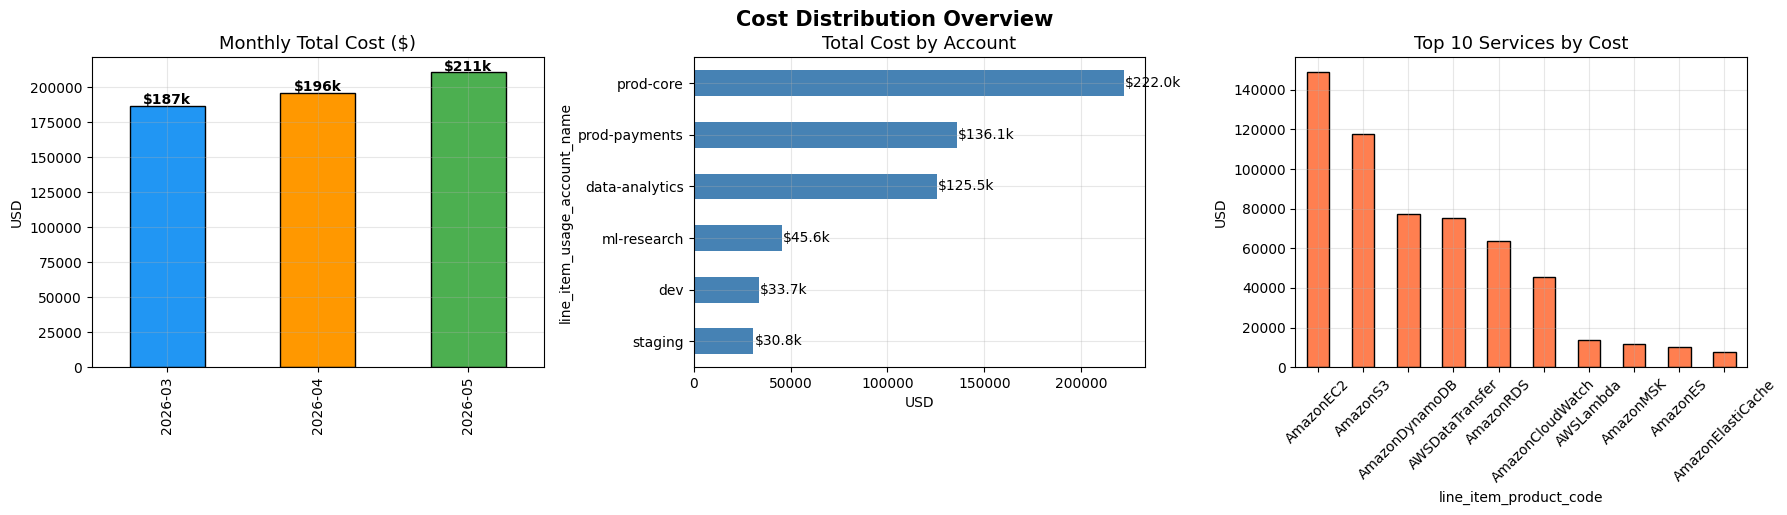

Monthly breakdown:
month
2026-03    $186,806
2026-04    $196,080
2026-05    $210,887
Freq: M, Name: line_item_unblended_cost, dtype: object

Growth Mar→May: 12.9%


In [3]:
## 3. Cost Distribution — Monthly, Per Account, Per Service

# Monthly totals
cur['month'] = cur['date'].dt.to_period('M')
monthly = cur.groupby('month')['line_item_unblended_cost'].sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Monthly
monthly.plot(kind='bar', ax=axes[0], color=['#2196F3','#FF9800','#4CAF50'], edgecolor='k')
axes[0].set_title('Monthly Total Cost ($)', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('USD')
for i, v in enumerate(monthly):
    axes[0].text(i, v + 1000, f'${v/1000:.0f}k', ha='center', fontweight='bold')

# Per account
acct_cost = cur.groupby('line_item_usage_account_name')['line_item_unblended_cost'].sum().sort_values()
acct_cost.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Total Cost by Account', fontsize=13)
axes[1].set_xlabel('USD')
for i, v in enumerate(acct_cost):
    axes[1].text(v + 500, i, f'${v/1000:.1f}k', va='center')

# Per service
svc_cost = cur.groupby('line_item_product_code')['line_item_unblended_cost'].sum().sort_values(ascending=False).head(10)
svc_cost.plot(kind='bar', ax=axes[2], color='coral', edgecolor='k')
axes[2].set_title('Top 10 Services by Cost', fontsize=13)
axes[2].set_ylabel('USD')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle('Cost Distribution Overview', y=1.02, fontsize=15, fontweight='bold')
plt.show()

print('Monthly breakdown:')
print(monthly.apply(lambda x: f'${x:,.0f}'))
print(f'\nGrowth Mar→May: {(monthly.iloc[-1]-monthly.iloc[0])/monthly.iloc[0]*100:.1f}%')

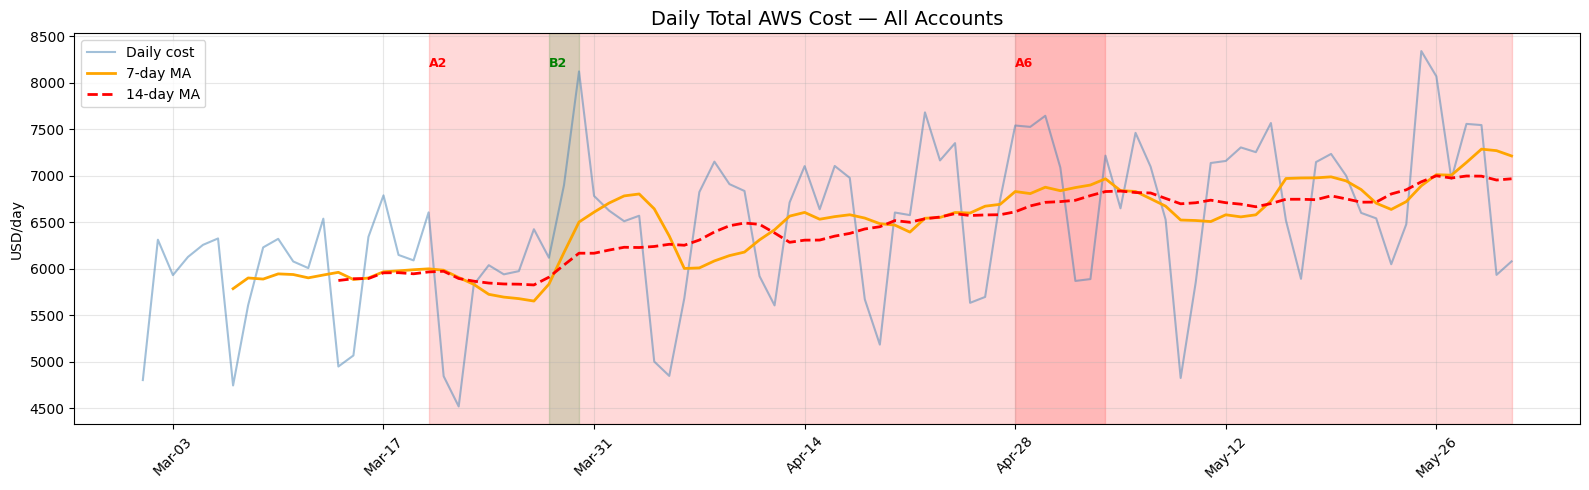

Daily stats: mean=$6,454, std=$825
Min: $4,521 | Max: $8,341
CV (std/mean): 0.128


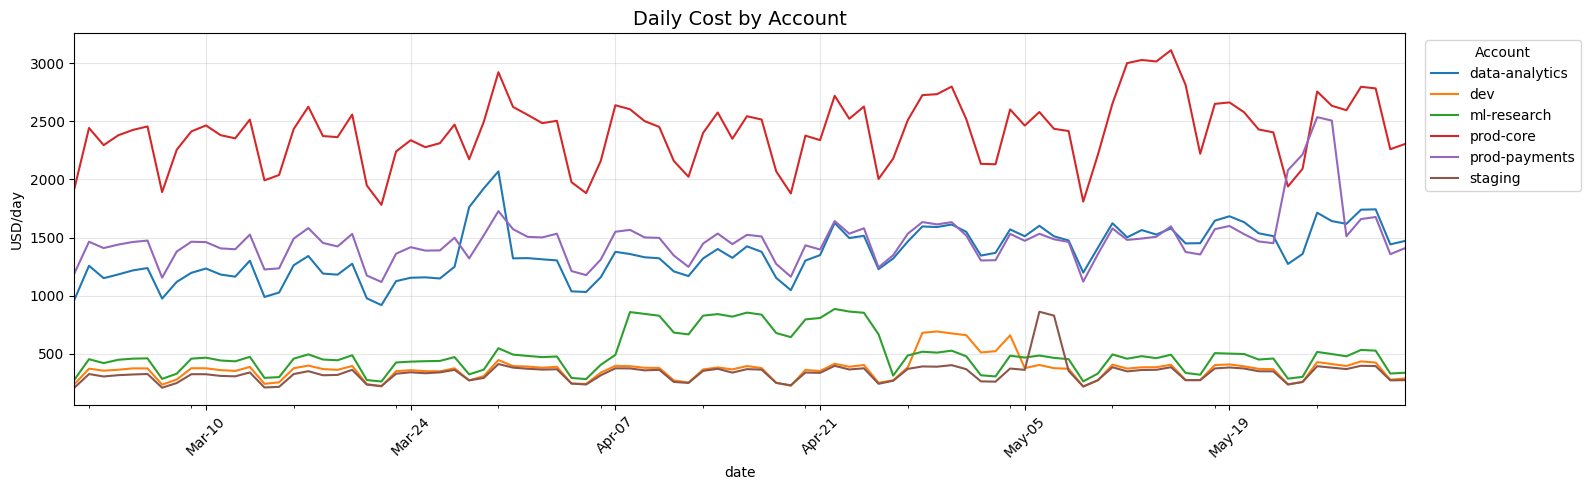

In [4]:
## 4. Daily Cost Time Series — Overall & Per Account

# Daily total cost
daily_total = cur.groupby('date')['line_item_unblended_cost'].sum().reset_index()
daily_total.columns = ['date', 'cost']

# Add rolling mean
daily_total['rolling_7d']  = daily_total['cost'].rolling(7).mean()
daily_total['rolling_14d'] = daily_total['cost'].rolling(14).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_total.date, daily_total.cost, alpha=0.5, color='steelblue', label='Daily cost')
ax.plot(daily_total.date, daily_total.rolling_7d,  color='orange', lw=2, label='7-day MA')
ax.plot(daily_total.date, daily_total.rolling_14d, color='red',    lw=2, linestyle='--', label='14-day MA')

# Mark labeled anomaly windows
for _, row in labels.iterrows():
    color = 'red' if row['label'] == 'anomaly' else 'green'
    ax.axvspan(row['start_date'], row['end_date'], color=color, alpha=0.15)
    ax.text(row['start_date'], daily_total.cost.max()*0.98,
            row['anomaly_id'], fontsize=9, color=color, fontweight='bold')

ax.set_title('Daily Total AWS Cost — All Accounts', fontsize=14)
ax.set_ylabel('USD/day')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Daily stats: mean=${daily_total.cost.mean():,.0f}, std=${daily_total.cost.std():,.0f}')
print(f'Min: ${daily_total.cost.min():,.0f} | Max: ${daily_total.cost.max():,.0f}')
print(f'CV (std/mean): {daily_total.cost.std()/daily_total.cost.mean():.3f}')

# Daily cost per account
daily_acct = cur.groupby(['date','line_item_usage_account_name'])['line_item_unblended_cost'].sum().unstack()

fig, ax = plt.subplots(figsize=(16, 5))
daily_acct.plot(ax=ax, lw=1.5)
ax.set_title('Daily Cost by Account', fontsize=14)
ax.set_ylabel('USD/day')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.legend(title='Account', bbox_to_anchor=(1.01,1))
plt.tight_layout()
plt.show()

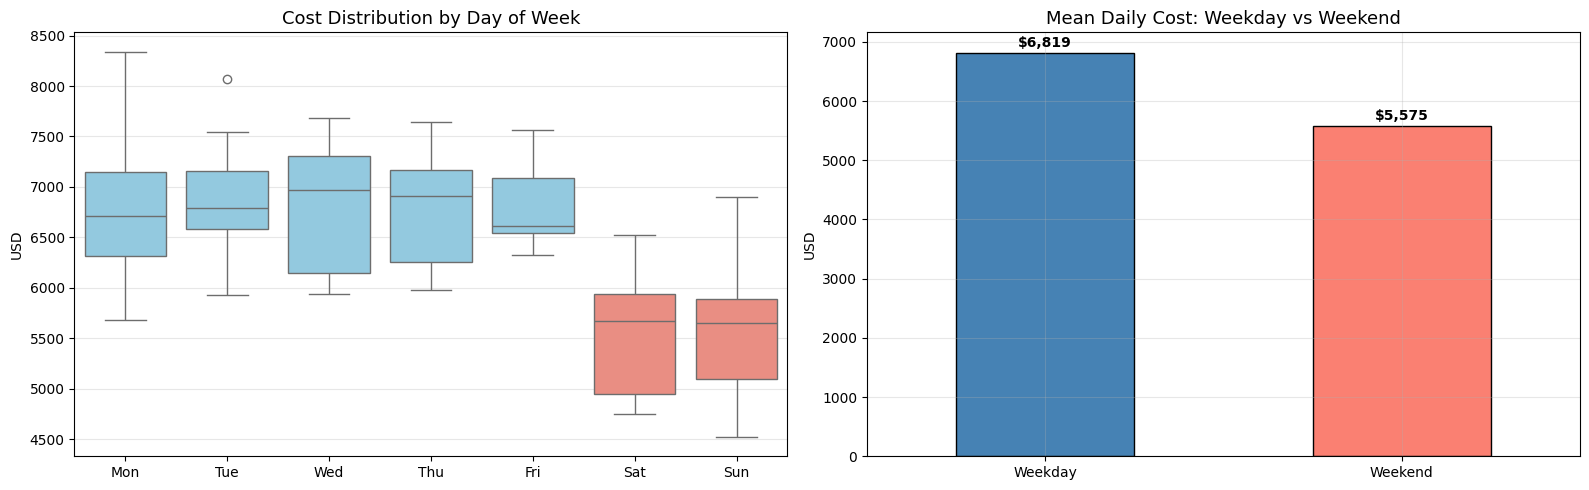

Weekday vs Weekend stats:
           mean  median    std
Weekday  6819.0  6784.0  591.0
Weekend  5575.0  5672.0  621.0

Weekday/Weekend cost ratio: 1.22x
→ Anomaly: runaway_usage = resource KHÔNG giảm cuối tuần (ratio gần 1.0 = đáng ngờ)


In [5]:
## 5. Seasonality & Weekday/Weekend Pattern

daily_total['dayofweek']  = daily_total['date'].dt.dayofweek  # 0=Mon, 6=Sun
daily_total['is_weekend'] = daily_total['dayofweek'].isin([5, 6])
daily_total['week_label'] = daily_total['dayofweek'].map(
    {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot by day of week
order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.boxplot(data=daily_total, x='week_label', y='cost', order=order, ax=axes[0],
            palette=['skyblue']*5+['salmon']*2)
axes[0].set_title('Cost Distribution by Day of Week', fontsize=13)
axes[0].set_ylabel('USD')
axes[0].set_xlabel('')

# Weekend vs weekday
wd_stats = daily_total.groupby('is_weekend')['cost'].agg(['mean','median','std'])
wd_stats.index = ['Weekday','Weekend']
wd_stats['mean'].plot(kind='bar', ax=axes[1], color=['steelblue','salmon'], edgecolor='k')
axes[1].set_title('Mean Daily Cost: Weekday vs Weekend', fontsize=13)
axes[1].set_ylabel('USD')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(wd_stats['mean']):
    axes[1].text(i, v+100, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('Weekday vs Weekend stats:')
print(wd_stats.round(0))
ratio = wd_stats.loc['Weekday','mean'] / wd_stats.loc['Weekend','mean']
print(f'\nWeekday/Weekend cost ratio: {ratio:.2f}x')
print('→ Anomaly: runaway_usage = resource KHÔNG giảm cuối tuần (ratio gần 1.0 = đáng ngờ)')

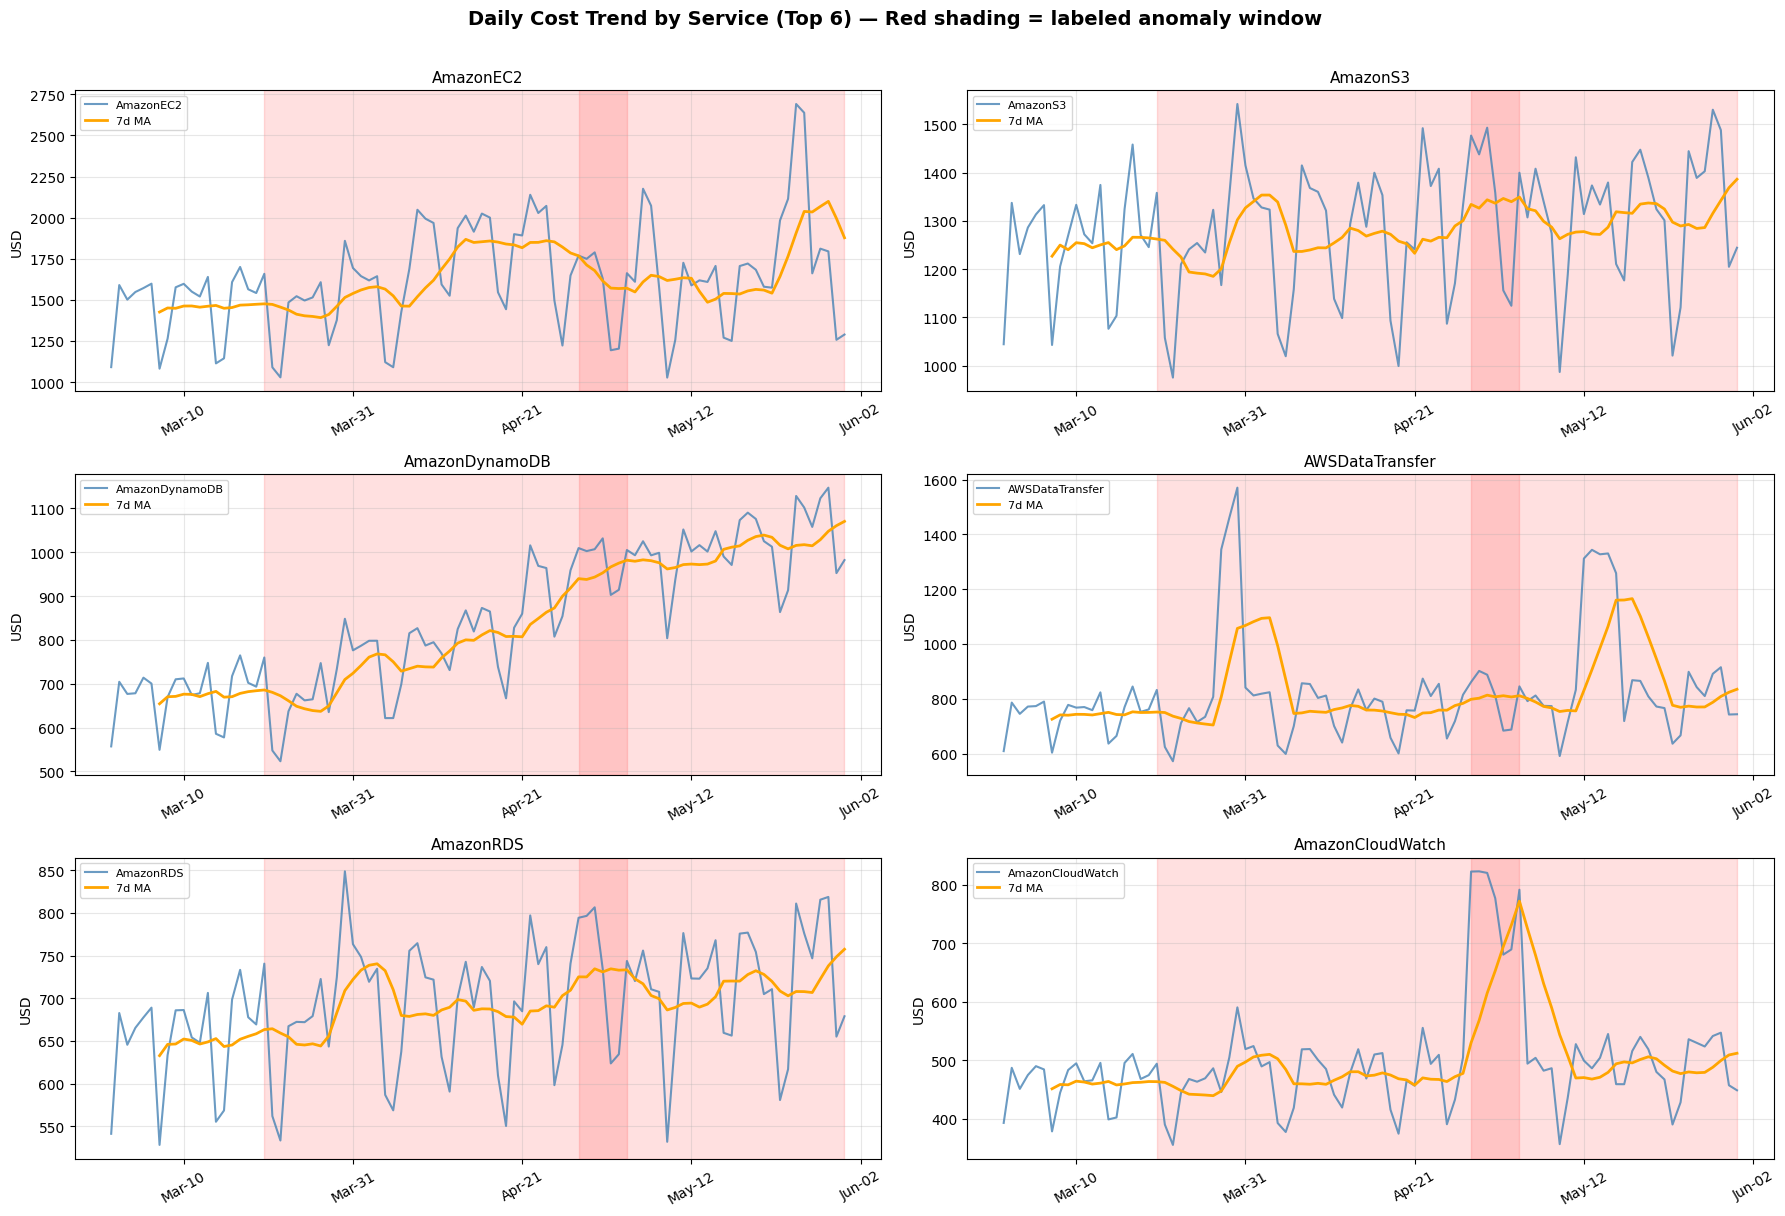

In [6]:
## 6. Per-Service Cost Trend & Anomaly Signals

# Daily cost per service (top 6)
top_services = cur.groupby('line_item_product_code')['line_item_unblended_cost'].sum()\
                  .nlargest(6).index.tolist()

daily_svc = cur[cur['line_item_product_code'].isin(top_services)]\
              .groupby(['date','line_item_product_code'])['line_item_unblended_cost'].sum().unstack()

fig, axes = plt.subplots(3, 2, figsize=(18, 12))
axes = axes.flatten()

for i, svc in enumerate(top_services):
    ax = axes[i]
    s = daily_svc[svc]
    ax.plot(s.index, s.values, color='steelblue', lw=1.5, alpha=0.8, label=svc)
    ax.plot(s.index, s.rolling(7).mean(), color='orange', lw=2, label='7d MA')
    for _, row in labels.iterrows():
        if row['label'] == 'anomaly':
            ax.axvspan(row['start_date'], row['end_date'], color='red', alpha=0.12)
    ax.set_title(svc, fontsize=11)
    ax.set_ylabel('USD')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=3))
    plt.setp(ax.get_xticklabels(), rotation=30)
    ax.legend(fontsize=8)

plt.suptitle('Daily Cost Trend by Service (Top 6) — Red shading = labeled anomaly window',
             y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Rows with |z| > 3: 5
                     date       account         service      cost    zscore
2026-05-23 00:00:00+00:00 prod-payments       AmazonEC2 1331.1629  3.456021
2026-05-06 00:00:00+00:00       staging       AmazonEC2  619.5623  3.360863
2026-05-12 00:00:00+00:00     prod-core AWSDataTransfer 1074.7175  3.211162
2026-04-08 00:00:00+00:00   ml-research       AmazonEC2  595.5512  3.077010
2026-04-26 00:00:00+00:00   ml-research       AmazonEC2   92.0915 -3.183009


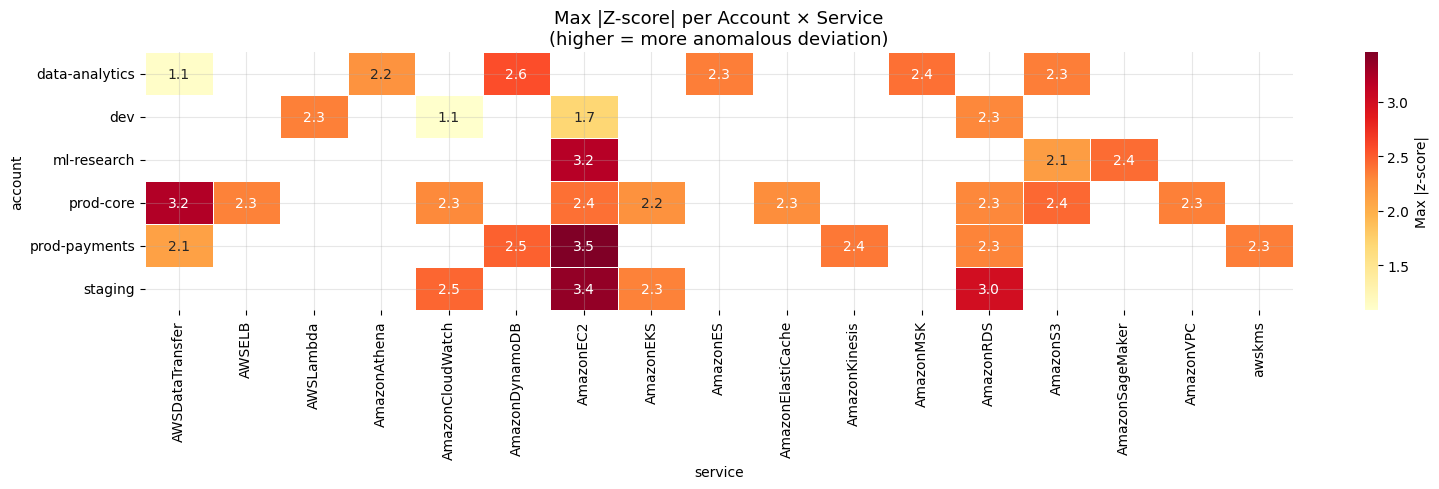


Top 10 (account, service) combos by max z-score:
account         service         
prod-payments   AmazonEC2           3.46
staging         AmazonEC2           3.36
prod-core       AWSDataTransfer     3.21
ml-research     AmazonEC2           3.18
staging         AmazonRDS           2.99
data-analytics  AmazonDynamoDB      2.57
prod-payments   AmazonDynamoDB      2.48
staging         AmazonCloudWatch    2.46
prod-core       AmazonS3            2.44
ml-research     AmazonSageMaker     2.42


In [7]:
## 7. Z-score Anomaly Signal — Daily Cost Deviation per Account×Service

# Compute rolling z-score per (account, service) — key detection signal
WINDOW = 14  # 14-day baseline window

daily_as = cur.groupby(['date','line_item_usage_account_name','line_item_product_code'])[
    'line_item_unblended_cost'].sum().reset_index()
daily_as.columns = ['date','account','service','cost']
daily_as = daily_as.sort_values(['account','service','date'])

daily_as['rolling_mean'] = daily_as.groupby(['account','service'])['cost']\
                                   .transform(lambda x: x.rolling(WINDOW, min_periods=3).mean())
daily_as['rolling_std']  = daily_as.groupby(['account','service'])['cost']\
                                   .transform(lambda x: x.rolling(WINDOW, min_periods=3).std())
daily_as['zscore'] = (daily_as['cost'] - daily_as['rolling_mean']) / (daily_as['rolling_std'] + 1e-9)

# High z-score days
high_z = daily_as[daily_as['zscore'].abs() > 3].sort_values('zscore', ascending=False)
print(f'Rows with |z| > 3: {len(high_z)}')
print(high_z[['date','account','service','cost','zscore']].head(20).to_string(index=False))

# Heatmap
pivot_z = daily_as.pivot_table(values='zscore', index='account', columns='service',
                                aggfunc=lambda x: x.abs().max())

plt.figure(figsize=(16, 5))
sns.heatmap(pivot_z, cmap='YlOrRd', annot=True, fmt='.1f', linewidths=0.5,
            cbar_kws={'label': 'Max |z-score|'})
plt.title('Max |Z-score| per Account × Service\n(higher = more anomalous deviation)', fontsize=13)
plt.tight_layout()
plt.show()

print('\nTop 10 (account, service) combos by max z-score:')
top_z = daily_as.groupby(['account','service'])['zscore'].apply(lambda x: x.abs().max())\
                .sort_values(ascending=False).head(10)
print(top_z.round(2).to_string())

Untagged rows: 92 (0.4%)
Untagged cost: $13,606.23
Tagged cost:   $580,167.11

Untagged cost by account:
line_item_usage_account_name
prod-payments    $13,606.23
Name: line_item_unblended_cost, dtype: object

Untagged cost by service:
line_item_product_code
AmazonEC2    $13,606.23
Name: line_item_unblended_cost, dtype: object


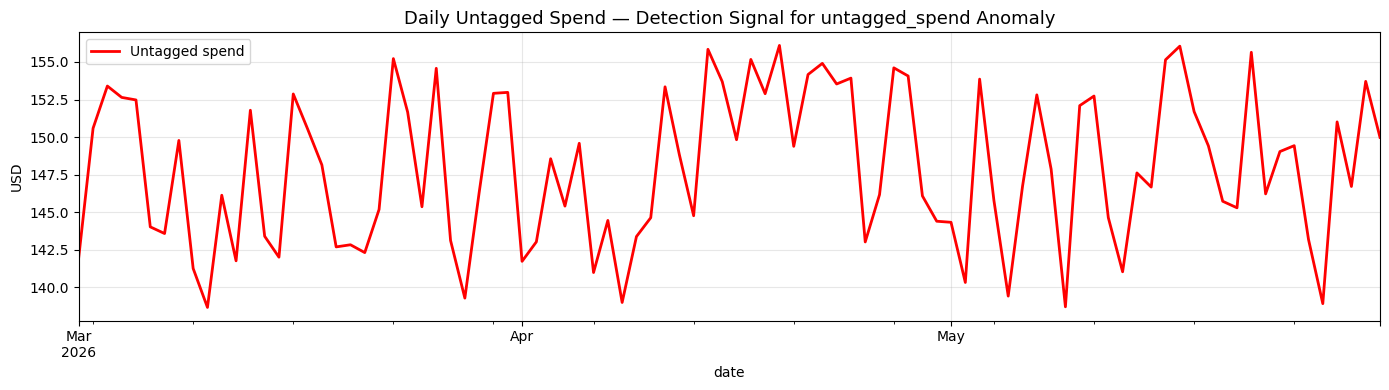

In [8]:
## 8. Untagged Spend Analysis (anomaly_type: untagged_spend)

cur['is_untagged'] = cur['resource_tags_user_team'].isna() | (cur['resource_tags_user_team'] == '')

untagged = cur[cur['is_untagged']]
tagged   = cur[~cur['is_untagged']]

print(f'Untagged rows: {len(untagged)} ({len(untagged)/len(cur)*100:.1f}%)')
print(f'Untagged cost: ${untagged["line_item_unblended_cost"].sum():,.2f}')
print(f'Tagged cost:   ${tagged["line_item_unblended_cost"].sum():,.2f}')

print('\nUntagged cost by account:')
print(untagged.groupby('line_item_usage_account_name')['line_item_unblended_cost'].sum()
              .sort_values(ascending=False).apply(lambda x: f'${x:,.2f}'))

print('\nUntagged cost by service:')
print(untagged.groupby('line_item_product_code')['line_item_unblended_cost'].sum()
              .sort_values(ascending=False).apply(lambda x: f'${x:,.2f}'))

# Daily untagged trend
daily_untagged = untagged.groupby('date')['line_item_unblended_cost'].sum()

fig, ax = plt.subplots(figsize=(14, 4))
daily_untagged.plot(ax=ax, color='red', lw=2, label='Untagged spend')
ax.set_title('Daily Untagged Spend — Detection Signal for untagged_spend Anomaly', fontsize=13)
ax.set_ylabel('USD')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
## 9. Resource-level Analysis — Idle Resource & Runaway Usage Detection

res_daily = cur.groupby(['line_item_resource_id','line_item_product_code',
                          'line_item_usage_account_name','date'])['line_item_unblended_cost'].sum().reset_index()

# Resources active on most days (potential idle)
res_active_days = res_daily.groupby('line_item_resource_id').agg(
    active_days=('date', 'count'),
    total_cost=('line_item_unblended_cost', 'sum'),
    mean_daily=('line_item_unblended_cost', 'mean'),
    std_daily=('line_item_unblended_cost', 'std'),
    account=('line_item_usage_account_name', 'first'),
    service=('line_item_product_code', 'first')
).reset_index()

res_active_days['cv'] = res_active_days['std_daily'] / (res_active_days['mean_daily'] + 1e-9)

# Idle candidate: active many days, low CV, moderate spend
idle_cand = res_active_days[
    (res_active_days['active_days'] >= 30) &
    (res_active_days['cv'] < 0.15) &
    (res_active_days['mean_daily'] > 5)
].sort_values('total_cost', ascending=False)

print(f'Idle candidates (stable cost, long-running): {len(idle_cand)}')
print(idle_cand[['line_item_resource_id','account','service','active_days','mean_daily','total_cost','cv']]
      .head(15).to_string(index=False))

# Runaway: high weekend cost ratio
res_daily_aug = res_daily.copy()
res_daily_aug['is_weekend'] = res_daily_aug['date'].dt.dayofweek.isin([5,6])

res_we = res_daily_aug.groupby('line_item_resource_id').apply(lambda g: pd.Series({
    'weekend_cost':  g[g.is_weekend]['line_item_unblended_cost'].sum(),
    'weekday_cost':  g[~g.is_weekend]['line_item_unblended_cost'].sum(),
    'total_cost':    g['line_item_unblended_cost'].sum(),
    'active_days':   g['date'].nunique(),
    'account':       g['line_item_usage_account_name'].iloc[0],
    'service':       g['line_item_product_code'].iloc[0],
    'first_seen':    g['date'].min()
})).reset_index()

res_we['weekend_daily_avg'] = res_we['weekend_cost'] / (res_we['active_days'] * 2/7 + 1e-9)
res_we['weekday_daily_avg'] = res_we['weekday_cost'] / (res_we['active_days'] * 5/7 + 1e-9)
res_we['we_ratio'] = res_we['weekend_daily_avg'] / (res_we['weekday_daily_avg'] + 1e-9)

runaway_cand = res_we[
    (res_we['we_ratio'] >= 0.9) &
    (res_we['total_cost'] > 100) &
    (res_we['active_days'] >= 7)
].sort_values('total_cost', ascending=False)

print(f'\nRunaway usage candidates (high weekend ratio): {len(runaway_cand)}')
print(runaway_cand[['line_item_resource_id','account','service','active_days','total_cost','we_ratio','first_seen']]
      .head(15).to_string(index=False))

Idle candidates (stable cost, long-running): 101
                line_item_resource_id        account          service  active_days  mean_daily  total_cost       cv
                          bucket-1220 data-analytics         AmazonS3           92  584.459501  53770.2741 0.107055
             res-awsdatatransfer-1053      prod-core  AWSDataTransfer           92  531.301621  48879.7491 0.108275
                          bucket-1054      prod-core         AmazonS3           92  492.186341  45281.1434 0.107041
              res-amazondynamodb-1067  prod-payments   AmazonDynamoDB           92  399.039812  36711.6627 0.107708
            res-amazoncloudwatch-1046      prod-core AmazonCloudWatch           92  347.938548  32010.3464 0.106624
              res-amazondynamodb-1230 data-analytics   AmazonDynamoDB           92  295.928034  27225.3791 0.107901
             res-awsdatatransfer-1146  prod-payments  AWSDataTransfer           92  234.782255  21599.9675 0.108557
                       

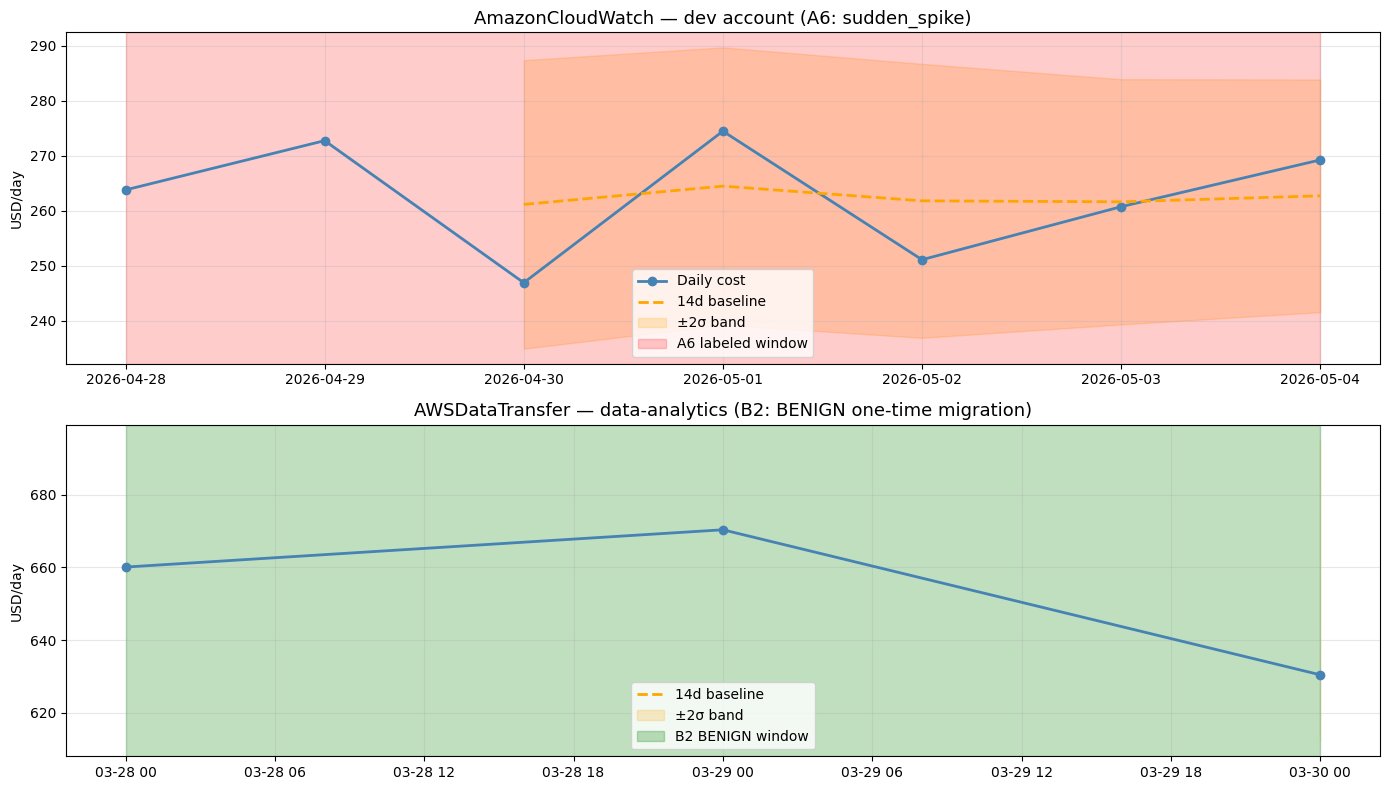

Key insight: A6 vs B2 look SIMILAR in z-score terms.
→ Pure z-score will flag B2 as FP. Need duration + context to distinguish anomaly from benign.



TypeError: Invalid comparison between dtype=datetime64[ns, UTC] and Timestamp

In [24]:
## 10. Sudden Spike Detection — A6 vs B2 Comparison

# A6: AmazonCloudWatch in 'dev' account (spike April 28 - May 4)
cw_dev = daily_as[(daily_as['account'] == 'dev') & (daily_as['service'] == 'AmazonCloudWatch')].copy()
cw_dev = cw_dev.sort_values('date').reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.plot(cw_dev.date, cw_dev.cost, 'o-', color='steelblue', lw=2, label='Daily cost')
ax.plot(cw_dev.date, cw_dev.rolling_mean, color='orange', lw=2, ls='--', label='14d baseline')
ax.fill_between(cw_dev.date,
                cw_dev.rolling_mean - 2*cw_dev.rolling_std,
                cw_dev.rolling_mean + 2*cw_dev.rolling_std,
                alpha=0.2, color='orange', label='±2σ band')
a6 = labels[labels['anomaly_id']=='A6'].iloc[0]
ax.axvspan(a6.start_date, a6.end_date, color='red', alpha=0.2, label='A6 labeled window')
ax.set_title('AmazonCloudWatch — dev account (A6: sudden_spike)', fontsize=13)
ax.set_ylabel('USD/day')
ax.legend()

# B2: benign migration — data-analytics AWSDataTransfer
dt_da = daily_as[(daily_as['account'] == 'data-analytics') & (daily_as['service'] == 'AWSDataTransfer')].copy()
dt_da = dt_da.sort_values('date').reset_index(drop=True)

ax = axes[1]
ax.plot(dt_da.date, dt_da.cost, 'o-', color='steelblue', lw=2)
ax.plot(dt_da.date, dt_da.rolling_mean, color='orange', lw=2, ls='--', label='14d baseline')
ax.fill_between(dt_da.date,
                dt_da.rolling_mean - 2*dt_da.rolling_std,
                dt_da.rolling_mean + 2*dt_da.rolling_std,
                alpha=0.2, color='orange', label='±2σ band')
b2 = labels[labels['anomaly_id']=='B2'].iloc[0]
ax.axvspan(b2.start_date, b2.end_date, color='green', alpha=0.25, label='B2 BENIGN window')
ax.set_title('AWSDataTransfer — data-analytics (B2: BENIGN one-time migration)', fontsize=13)
ax.set_ylabel('USD/day')
ax.legend()

plt.tight_layout()
plt.show()

print('Key insight: A6 vs B2 look SIMILAR in z-score terms.')
print('→ Pure z-score will flag B2 as FP. Need duration + context to distinguish anomaly from benign.')
print()
a6_window = cw_dev[(cw_dev['date'] >= a6.start_date) & (cw_dev['date'] <= a6.end_date)]
print(f'A6 peak z-score: {a6_window["zscore"].max():.2f} | duration: {(a6.end_date - a6.start_date).days}d')
b2_window = dt_da[(dt_da['date'] >= b2.start_date) & (dt_da['date'] <= b2.end_date)]
print(f'B2 peak z-score: {b2_window["zscore"].max():.2f} | duration: {(b2.end_date - b2.start_date).days}d')

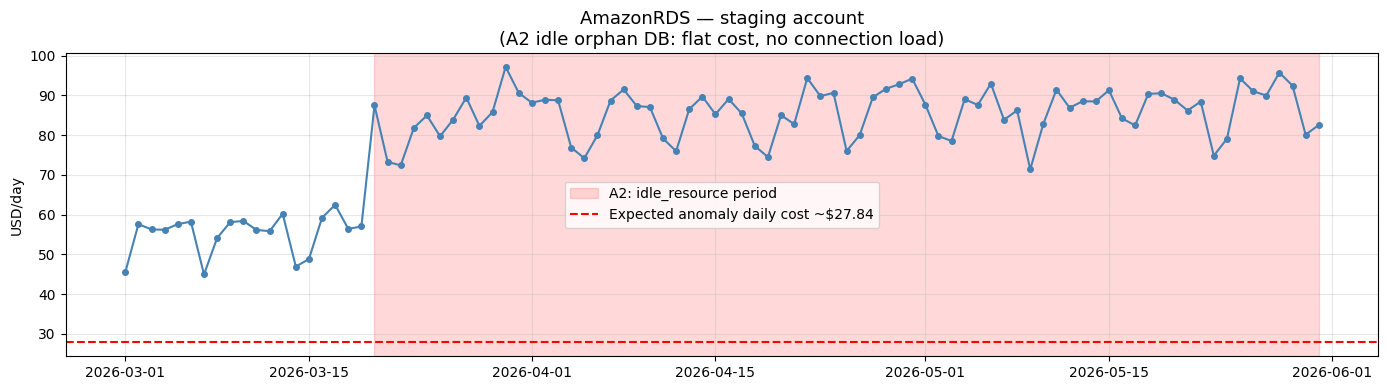

Orphan DB metrics rows: 73
Label distribution: {'anomaly': 73}
Avg database_connections: 0.55
Avg CPU: 1.79%


In [11]:
## 11. Idle Resource Deep-Dive — A2: RDS staging orphan

a2 = labels[labels['anomaly_id']=='A2'].iloc[0]
rds_staging = cur[
    (cur['line_item_product_code'] == 'AmazonRDS') &
    (cur['line_item_usage_account_name'] == 'staging')
].groupby('date')['line_item_unblended_cost'].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rds_staging.index, rds_staging.values, 'o-', color='steelblue', ms=4, lw=1.5)
ax.axvspan(a2.start_date, a2.end_date, color='red', alpha=0.15, label='A2: idle_resource period')
ax.axhline(a2.approx_daily_cost, color='red', ls='--', lw=1.5,
           label=f'Expected anomaly daily cost ~${a2.approx_daily_cost}')
ax.set_title('AmazonRDS — staging account\n(A2 idle orphan DB: flat cost, no connection load)', fontsize=13)
ax.set_ylabel('USD/day')
ax.legend()
plt.tight_layout()
plt.show()

# Cross-check with RDS metrics
orphan_id = a2.resource_id
if orphan_id in rds_m['resource_id'].values:
    orphan_metrics = rds_m[rds_m['resource_id'] == orphan_id].copy()
    print(f'Orphan DB metrics rows: {len(orphan_metrics)}')
    print(f'Label distribution: {orphan_metrics["label"].value_counts().to_dict()}')
    print(f'Avg database_connections: {orphan_metrics["database_connections"].mean():.2f}')
    print(f'Avg CPU: {orphan_metrics["cpu_percent"].mean():.2f}%')
else:
    print(f'Resource {orphan_id} not found in rds_metrics — checking low-connection candidates:')
    print(rds_m.groupby('resource_id').agg(
        mean_conn=('database_connections','mean'),
        mean_cpu=('cpu_percent','mean'),
        label_mode=('label', lambda x: x.mode()[0])
    ).sort_values('mean_conn').head(10).to_string())

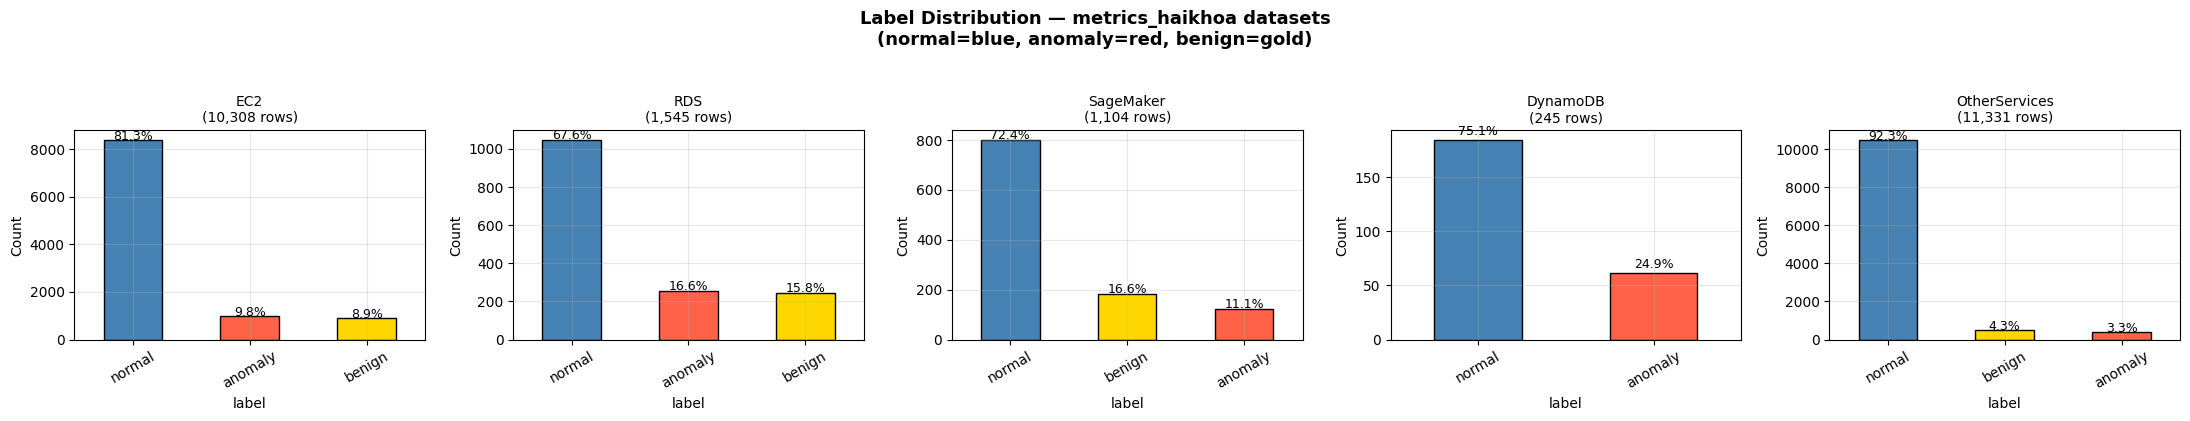

Service         |   total |  anomaly% |  benign% | imbalance_ratio
-----------------------------------------------------------------
EC2             |   10308 |      9.8% |     8.9% |          0.120
RDS             |    1545 |     16.6% |    15.8% |          0.245
SageMaker       |    1104 |     11.1% |    16.6% |          0.153
DynamoDB        |     245 |     24.9% |     0.0% |          0.332
OtherServices   |   11331 |      3.3% |     4.3% |          0.036

→ Imbalance ratio < 0.2 = cần class_weight / SMOTE khi dùng supervised model trên metrics


In [13]:
## 12. Metrics EDA — Label Distribution Across All Services
# Mục đích: hiểu tỉ lệ anomaly/normal/benign trong từng nguồn metrics,
# xác định mức độ mất cân bằng nhãn trước khi chọn model.

metrics_info = {
    'EC2':          ec2_m,
    'RDS':          rds_m,
    'SageMaker':    sm_m,
    'DynamoDB':     ddb_m,
    'OtherServices': other_m
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, (name, df) in enumerate(metrics_info.items()):
    counts = df['label'].value_counts()
    colors = {'normal':'steelblue','anomaly':'tomato','benign':'gold'}
    bar_colors = [colors.get(l,'gray') for l in counts.index]
    counts.plot(kind='bar', ax=axes[i], color=bar_colors, edgecolor='k')
    axes[i].set_title(f'{name}\n({len(df):,} rows)', fontsize=10)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(counts):
        pct = v/len(df)*100
        axes[i].text(j, v+5, f'{pct:.1f}%', ha='center', fontsize=9)

plt.suptitle('Label Distribution — metrics_haikhoa datasets\n(normal=blue, anomaly=red, benign=gold)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

# Summary table
print(f"{'Service':15s} | {'total':>7} | {'anomaly%':>9} | {'benign%':>8} | {'imbalance_ratio':>15}")
print('-' * 65)
for name, df in metrics_info.items():
    counts  = df['label'].value_counts()
    total   = len(df)
    anom    = counts.get('anomaly', 0)
    benign  = counts.get('benign', 0)
    normal  = counts.get('normal', 0)
    ratio   = anom / (normal + 1e-9)
    print(f'{name:15s} | {total:>7} | {anom/total*100:>8.1f}% | {benign/total*100:>7.1f}% | {ratio:>14.3f}')

print('\n→ Imbalance ratio < 0.2 = cần class_weight / SMOTE khi dùng supervised model trên metrics')

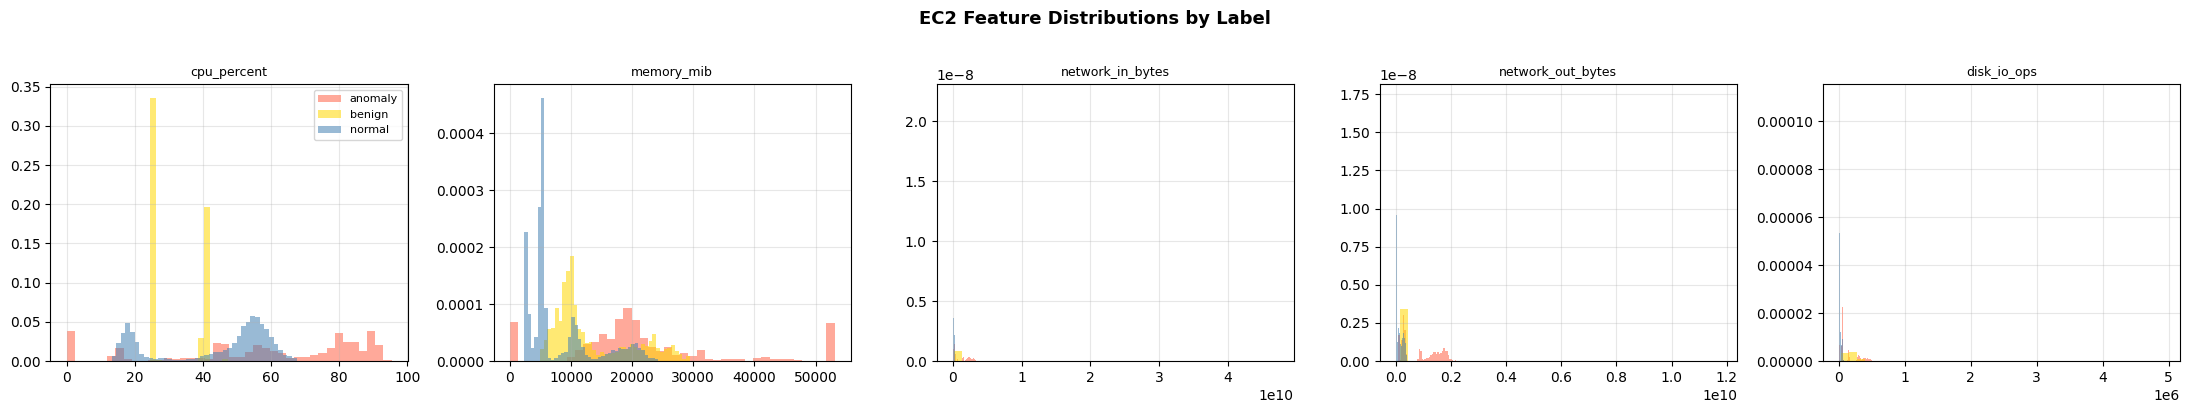

EC2 — KS test (anomaly vs normal):
  cpu_percent                   : KS=0.480, p=0.0000 ***
  memory_mib                    : KS=0.692, p=0.0000 ***
  network_in_bytes              : KS=0.703, p=0.0000 ***
  network_out_bytes             : KS=0.646, p=0.0000 ***
  disk_io_ops                   : KS=0.639, p=0.0000 ***

RDS — database_connections distribution by label:
          count  mean   std   min   25%   50%   75%    max
label                                                     
anomaly   256.0  50.7  63.4   0.0   1.0  26.0  34.2  198.0
benign    244.0  28.9   7.2  10.0  25.0  29.0  34.0   44.0
normal   1045.0  24.2   5.7  10.0  21.0  25.0  28.0   37.0


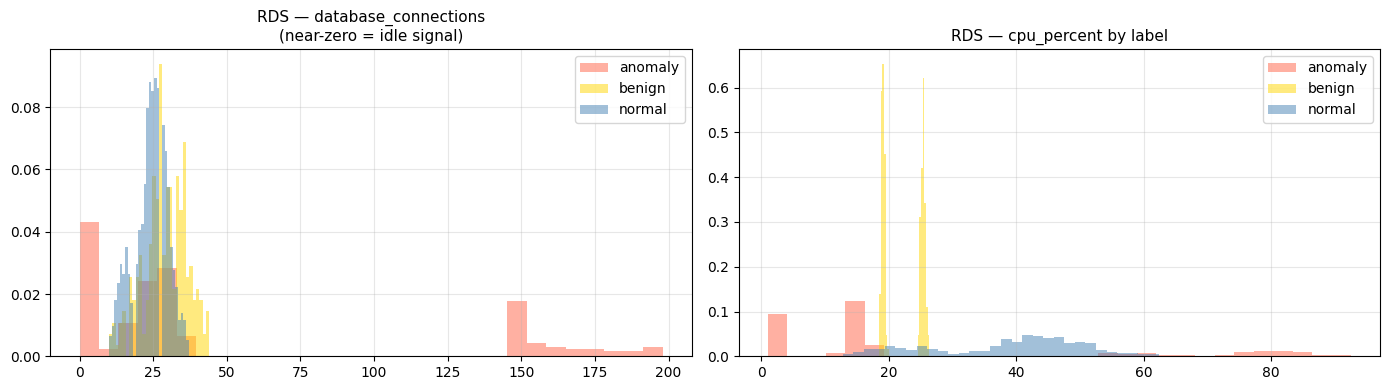

In [14]:
## 13. Metrics EDA — Feature Distributions by Label (EC2 & RDS)
# So sánh phân phối CPU, memory, network giữa normal / anomaly / benign
# để biết feature nào discriminate tốt nhất.

from scipy import stats

# --- EC2 features ---
ec2_feats = ['cpu_percent', 'memory_mib', 'network_in_bytes', 'network_out_bytes', 'disk_io_ops']
fig, axes = plt.subplots(1, len(ec2_feats), figsize=(22, 4))
for i, feat in enumerate(ec2_feats):
    for lbl, grp in ec2_m.groupby('label'):
        color = {'normal':'steelblue','anomaly':'tomato','benign':'gold'}.get(lbl,'gray')
        axes[i].hist(grp[feat].dropna(), bins=40, alpha=0.55, label=lbl, density=True, color=color)
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('')
    if i == 0:
        axes[i].legend(fontsize=8)
plt.suptitle('EC2 Feature Distributions by Label', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# KS test: anomaly vs normal
print('EC2 — KS test (anomaly vs normal):')
for feat in ec2_feats:
    n = ec2_m[ec2_m['label']=='normal'][feat].dropna()
    a = ec2_m[ec2_m['label']=='anomaly'][feat].dropna()
    ks, p = stats.ks_2samp(n, a)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else '')
    print(f'  {feat:30s}: KS={ks:.3f}, p={p:.4f} {sig}')

# --- RDS: database_connections là key idle-signal ---
print('\nRDS — database_connections distribution by label:')
print(rds_m.groupby('label')['database_connections'].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for lbl, grp in rds_m.groupby('label'):
    color = {'normal':'steelblue','anomaly':'tomato','benign':'gold'}.get(lbl,'gray')
    axes[0].hist(grp['database_connections'].dropna(), bins=30, alpha=0.5, label=lbl,
                 density=True, color=color)
    axes[1].hist(grp['cpu_percent'].dropna(), bins=30, alpha=0.5, label=lbl,
                 density=True, color=color)
axes[0].set_title('RDS — database_connections\n(near-zero = idle signal)', fontsize=11)
axes[1].set_title('RDS — cpu_percent by label', fontsize=11)
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.show()

=== SageMaker metrics overview ===
        cpu_percent                                           gpu_utilization                                          memory_mib                                                        
              count  mean   std   min   25%   50%   75%   max           count  mean  std   min   25%   50%   75%   max      count    mean     std     min     25%     50%     75%     max
label                                                                                                                                                                                    
anomaly       122.0  27.7  14.3  13.1  15.1  18.4  43.5  55.5           122.0  19.1  3.9   9.8  16.2  20.0  22.1  26.3      122.0  5080.2  1589.8  2364.9  3935.1  4796.7  6113.3  7782.4
benign        183.0  27.5   0.3  26.7  27.3  27.5  27.7  28.3           183.0  21.4  0.1  21.0  21.3  21.4  21.5  22.0      183.0  4291.0   728.5  2488.6  3830.5  4446.6  4822.2  5739.3
normal        799.0  29.2   9.3   9

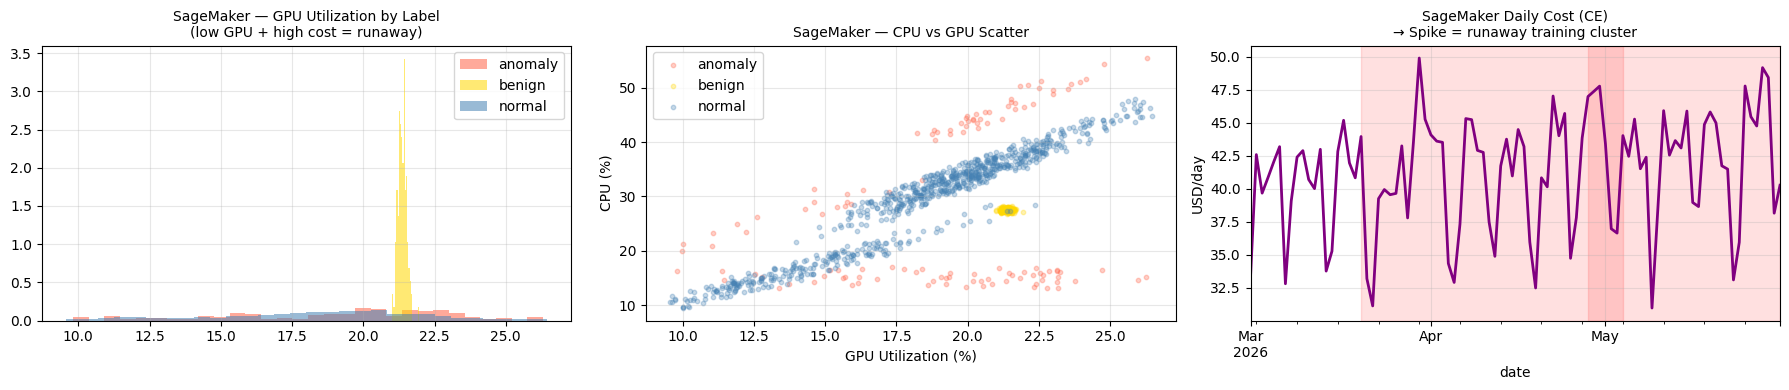


=== Key Insight: SageMaker ===
- Anomaly GPU util vs Normal GPU util diff:
  normal    : mean=18.4%, median=19.0%, std=3.7%
  anomaly   : mean=19.1%, median=20.0%, std=3.9%
- Runaway: training cluster chạy 24/7 nhưng GPU util thấp = resource bị quên không terminate


In [15]:
## 14. Metrics EDA — SageMaker GPU Utilization & Runaway Training Signal
# SageMaker là nguồn chứa training cluster GPU — loại anomaly runaway_usage điển hình.
# GPU utilization thấp mà cost cao = provisioned but idle / misconfigured.

print('=== SageMaker metrics overview ===')
print(sm_m.groupby('label')[['cpu_percent','gpu_utilization','memory_mib']].describe().round(1).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# GPU utilization by label
for lbl, grp in sm_m.groupby('label'):
    color = {'normal':'steelblue','anomaly':'tomato','benign':'gold'}.get(lbl,'gray')
    axes[0].hist(grp['gpu_utilization'].dropna(), bins=30, alpha=0.55,
                 label=lbl, density=True, color=color)
axes[0].set_title('SageMaker — GPU Utilization by Label\n(low GPU + high cost = runaway)',
                   fontsize=10)
axes[0].legend()

# CPU vs GPU scatter — anomaly cluster
for lbl, grp in sm_m.groupby('label'):
    color = {'normal':'steelblue','anomaly':'tomato','benign':'gold'}.get(lbl,'gray')
    axes[1].scatter(grp['gpu_utilization'], grp['cpu_percent'],
                    alpha=0.3, s=10, label=lbl, color=color)
axes[1].set_xlabel('GPU Utilization (%)')
axes[1].set_ylabel('CPU (%)')
axes[1].set_title('SageMaker — CPU vs GPU Scatter', fontsize=10)
axes[1].legend()

# SageMaker daily cost from CE (training cluster spend)
sm_ce = ce[ce['service_code'] == 'AmazonSageMaker'].groupby('date')['unblended_cost'].sum()
sm_ce.plot(ax=axes[2], color='purple', lw=2)
axes[2].set_title('SageMaker Daily Cost (CE)\n→ Spike = runaway training cluster', fontsize=10)
axes[2].set_ylabel('USD/day')
for _, row in labels[labels['label']=='anomaly'].iterrows():
    axes[2].axvspan(row['start_date'], row['end_date'], color='red', alpha=0.12)

plt.tight_layout()
plt.show()

# Insight box
print('\n=== Key Insight: SageMaker ===')
print('- Anomaly GPU util vs Normal GPU util diff:')
for lbl in ['normal','anomaly']:
    sub = sm_m[sm_m['label']==lbl]['gpu_utilization']
    print(f'  {lbl:10s}: mean={sub.mean():.1f}%, median={sub.median():.1f}%, std={sub.std():.1f}%')
print('- Runaway: training cluster chạy 24/7 nhưng GPU util thấp = resource bị quên không terminate')

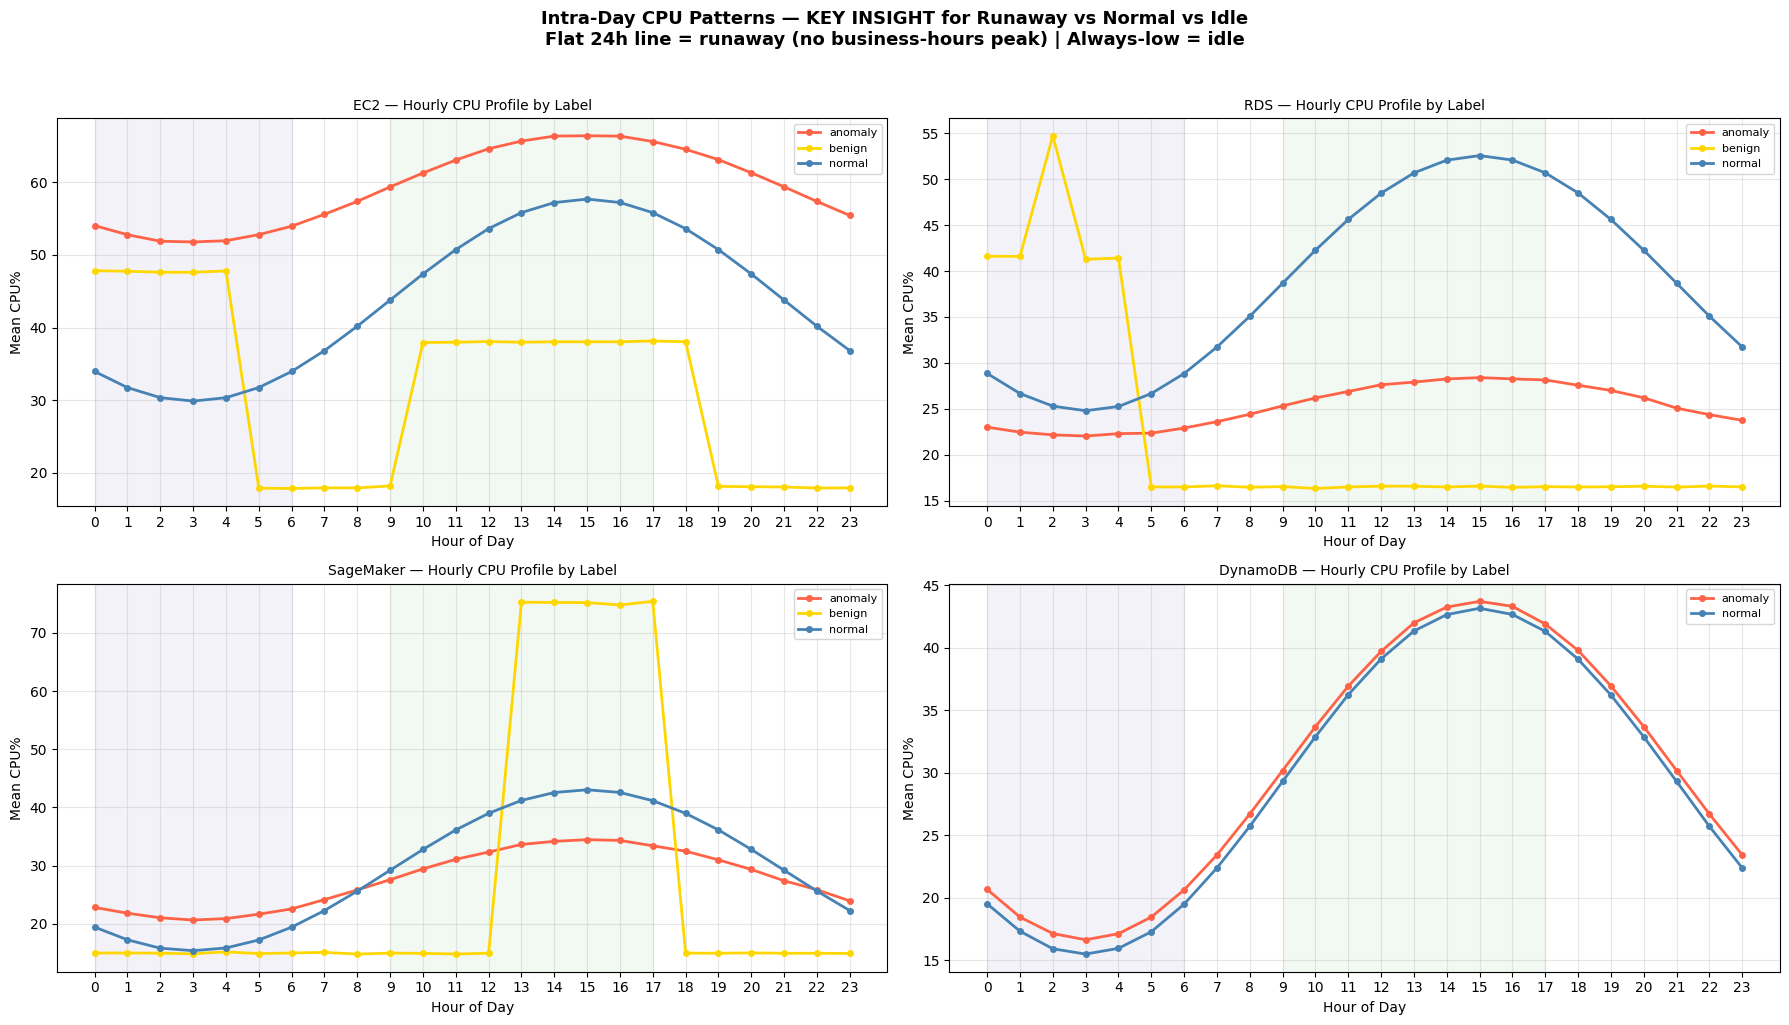

=== Hourly CPU Variance (std across 24h) — Anomaly Signal ===
High std = normal diurnal pattern | Low std = flat = runaway or idle

EC2:
          mean  median
label                 
anomaly   6.21    8.10
benign   22.40   21.32
normal   10.05   10.80

RDS:
          mean  median
label                 
anomaly   3.28    1.69
benign   13.18   13.20
normal   10.04   10.80

SageMaker:
          mean  median
label                 
anomaly   5.84    4.09
benign   25.01   25.02
normal    9.99   10.80


In [16]:
## 15. Metrics EDA — Hourly CPU Profile Analysis (cpu_h0..cpu_h23)
# cpu_h0..cpu_h23 là profile CPU theo từng giờ trong ngày.
# Insight quan trọng:
#   - Normal workload: thấp ban đêm (h0-h6), cao ban ngày (h8-h18)
#   - Runaway: flat 24/7 → không có peak/trough — đây là tín hiệu mạnh nhất
#   - Idle: luôn thấp 24h → CV giờ rất nhỏ

cpu_hour_cols = [f'cpu_h{h}' for h in range(24)]

def plot_hourly_profile(df, title, ax, label_col='label'):
    """Plot mean hourly CPU profile per label class."""
    for lbl, grp in df.groupby(label_col):
        mean_profile = grp[cpu_hour_cols].mean()
        color = {'normal':'steelblue','anomaly':'tomato','benign':'gold'}.get(lbl,'gray')
        ax.plot(range(24), mean_profile.values, marker='o', ms=4, lw=2, label=lbl, color=color)
    ax.set_xticks(range(24))
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Mean CPU%')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.axvspan(0, 6,   alpha=0.05, color='navy',  label='Night')
    ax.axvspan(9, 17,  alpha=0.05, color='green', label='Business hours')

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

plot_hourly_profile(ec2_m, 'EC2 — Hourly CPU Profile by Label',       axes[0,0])
plot_hourly_profile(rds_m, 'RDS — Hourly CPU Profile by Label',       axes[0,1])
plot_hourly_profile(sm_m,  'SageMaker — Hourly CPU Profile by Label', axes[1,0])
plot_hourly_profile(ddb_m, 'DynamoDB — Hourly CPU Profile by Label',  axes[1,1])

plt.suptitle('Intra-Day CPU Patterns — KEY INSIGHT for Runaway vs Normal vs Idle\n'
             'Flat 24h line = runaway (no business-hours peak) | Always-low = idle',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Quantify hourly variance as anomaly signal
print('=== Hourly CPU Variance (std across 24h) — Anomaly Signal ===')
print('High std = normal diurnal pattern | Low std = flat = runaway or idle')
for name, df in [('EC2', ec2_m), ('RDS', rds_m), ('SageMaker', sm_m)]:
    df = df.copy()
    df['hourly_std'] = df[cpu_hour_cols].std(axis=1)
    grp_stats = df.groupby('label')['hourly_std'].agg(['mean','median'])
    print(f'\n{name}:')
    print(grp_stats.round(2).to_string())

=== DynamoDB metrics ===
        cpu_percent                                           memory_mib                                                         network_in_bytes                                                                                                  
              count  mean   std   min   25%   50%   75%   max      count    mean     std     min     25%     50%     75%     max            count          mean           std           min           25%           50%           75%           max
label                                                                                                                                                                                                                                              
anomaly        61.0  30.2  11.0  11.6  21.4  31.8  39.9  46.9       61.0  4379.9  1102.2  2420.8  3380.8  4869.9  5325.0  5757.2             61.0  6.266677e+09  4.116165e+09  6.287959e+08  2.259659e+09  7.021566e+09  1.026776e+10  1.355163e+10

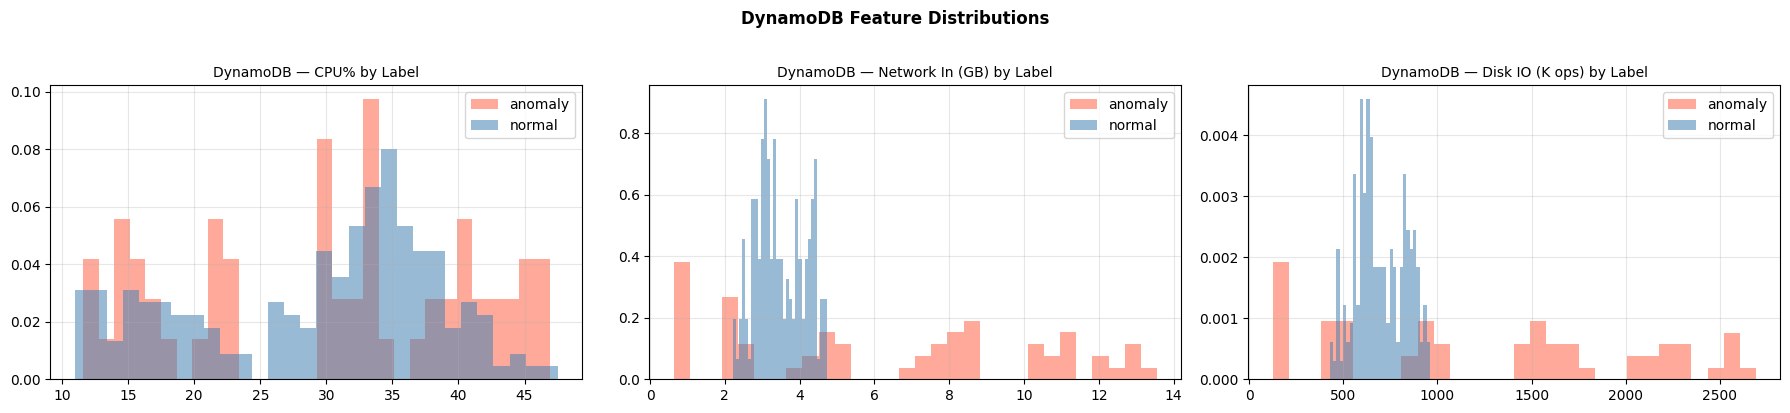


=== Other Services — resource_id prefix (service type) ===
label              anomaly  benign  normal
svc_type                                  
amazonathena             0       0       1
amazoncloudwatch         0       0       2
amazoneks                0       0       5
amazonelasticache        0       0       6
amazones                 0       0      10
amazonkinesis            2       3      30
amazonmsk                0       0       9
amazonvpc                0       0       6
awsdatatransfer          0       0       2
awselb                   0       0       8
awskms                   4       5      40
awslambda                0       0       1


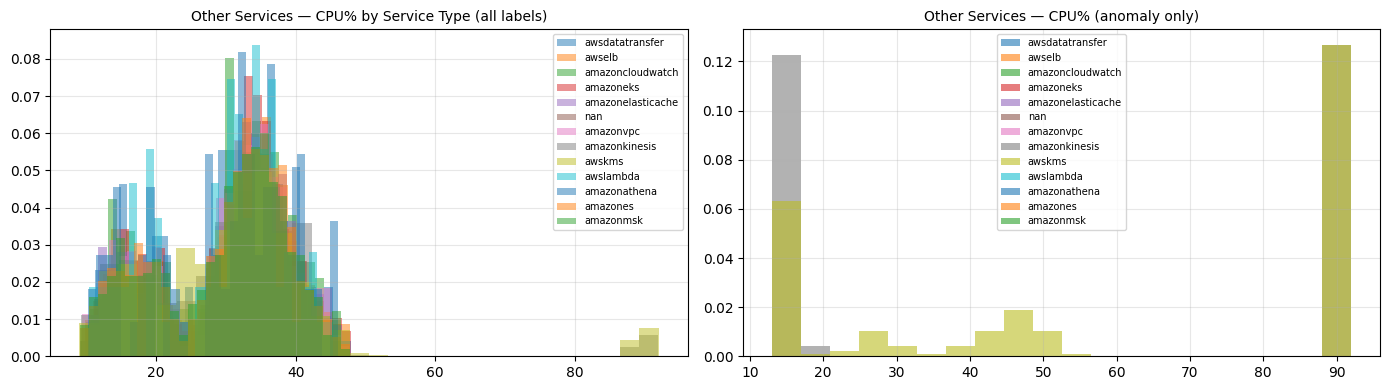

In [17]:
## 16. Metrics EDA — DynamoDB & Other Services Overview
# DynamoDB: high-throughput NoSQL — anomaly thường là throttling hoặc runaway scan
# Other Services: ELB, ElastiCache, EKS, CloudWatch, DataTransfer

# DynamoDB
print('=== DynamoDB metrics ===')
print(ddb_m[['cpu_percent','memory_mib','network_in_bytes','label']].groupby('label').describe().round(1).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for lbl, grp in ddb_m.groupby('label'):
    color = {'normal':'steelblue','anomaly':'tomato','benign':'gold'}.get(lbl,'gray')
    axes[0].hist(grp['cpu_percent'].dropna(), bins=30, alpha=0.55, label=lbl, density=True, color=color)
    axes[1].hist(grp['network_in_bytes'].dropna()/1e9, bins=30, alpha=0.55, label=lbl, density=True, color=color)
    axes[2].hist(grp['disk_io_ops'].dropna()/1e3, bins=30, alpha=0.55, label=lbl, density=True, color=color)
axes[0].set_title('DynamoDB — CPU% by Label', fontsize=10)
axes[1].set_title('DynamoDB — Network In (GB) by Label', fontsize=10)
axes[2].set_title('DynamoDB — Disk IO (K ops) by Label', fontsize=10)
for ax in axes: ax.legend()
plt.suptitle('DynamoDB Feature Distributions', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Other Services — service type breakdown
print('\n=== Other Services — resource_id prefix (service type) ===')
other_m['svc_type'] = other_m['resource_id'].str.extract(r'res-([a-z]+)-')[0]
print(other_m.groupby(['svc_type','label'])['resource_id'].nunique().unstack(fill_value=0).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
svc_types = other_m['svc_type'].unique()
colors_cycle = plt.cm.tab10.colors
for i, svc in enumerate(svc_types):
    sub = other_m[other_m['svc_type'] == svc]
    axes[0].hist(sub['cpu_percent'].dropna(), bins=30, alpha=0.5,
                 label=svc, color=colors_cycle[i % 10], density=True)
    axes[1].hist(sub[sub['label']=='anomaly']['cpu_percent'].dropna(), bins=20,
                 alpha=0.6, label=svc, color=colors_cycle[i % 10], density=True)
axes[0].set_title('Other Services — CPU% by Service Type (all labels)', fontsize=10)
axes[1].set_title('Other Services — CPU% (anomaly only)', fontsize=10)
for ax in axes: ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

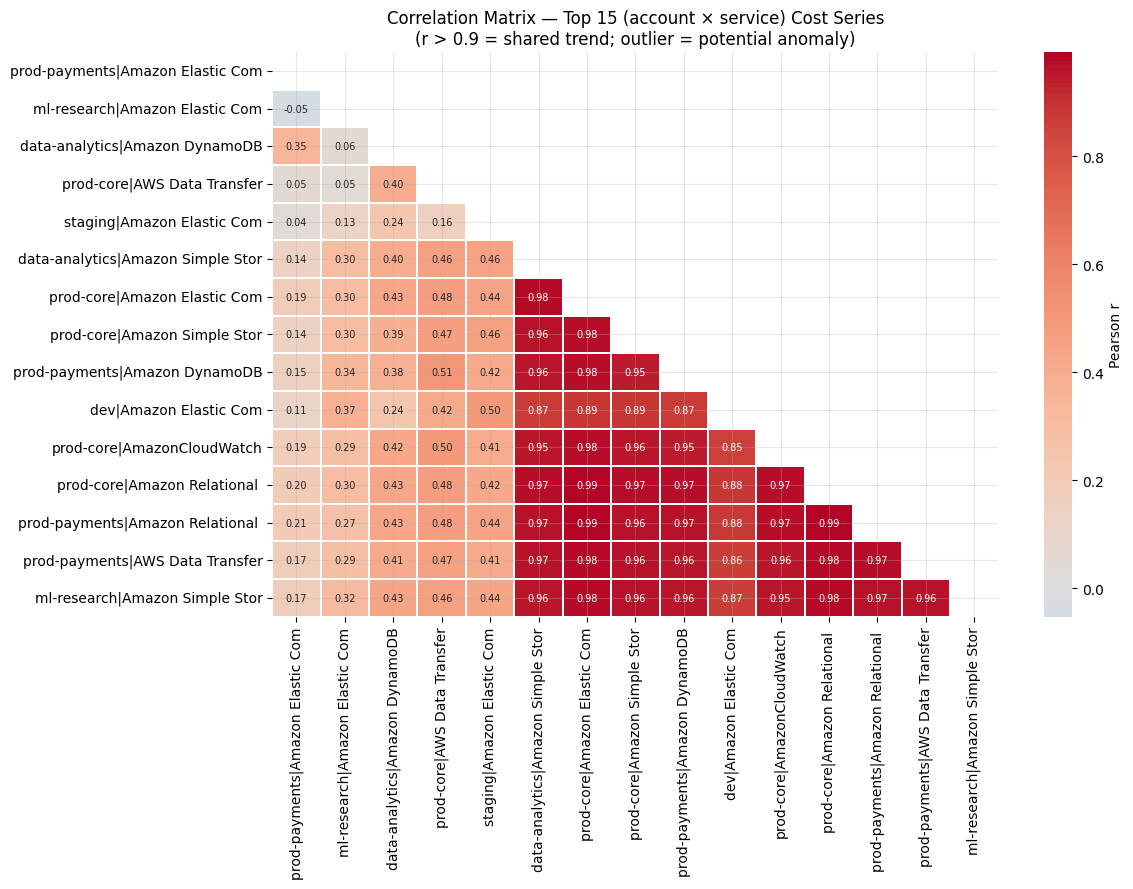

Highly correlated pairs (r > 0.9): 36
  prod-core|Amazon Elastic Com        <-> prod-core|Amazon Relational        : r=0.993
  prod-core|Amazon Elastic Com        <-> prod-payments|Amazon Relational    : r=0.99
  prod-core|Amazon Relational         <-> prod-payments|Amazon Relational    : r=0.986
  prod-core|Amazon Elastic Com        <-> ml-research|Amazon Simple Stor     : r=0.979
  data-analytics|Amazon Simple Stor   <-> prod-core|Amazon Elastic Com       : r=0.977
  prod-core|Amazon Elastic Com        <-> prod-payments|AWS Data Transfer    : r=0.977
  prod-core|Amazon Relational         <-> prod-payments|AWS Data Transfer    : r=0.977
  prod-core|Amazon Relational         <-> ml-research|Amazon Simple Stor     : r=0.977
  prod-core|Amazon Elastic Com        <-> prod-core|Amazon Simple Stor       : r=0.976
  prod-core|Amazon Elastic Com        <-> prod-payments|Amazon DynamoDB      : r=0.976

Insight: anomaly series sẽ có correlation thấp hơn đột ngột với các series bình thường.
→ Ro

In [18]:
## 17. Cross-Correlation — Cost Series & Decorrelation as Anomaly Signal
# Series highly correlated = share organic growth trend.
# Anomaly BREAKS this correlation → decorrelation = detection signal.

ce_pivot = ce.pivot_table(values='unblended_cost', index='date',
                           columns=['linked_account_name','service'], aggfunc='sum')
ce_pivot.columns = [f'{a}|{s[:18]}' for a,s in ce_pivot.columns]

# Top 15 series by variance
top_var = ce_pivot.var().nlargest(15).index
corr = ce_pivot[top_var].corr()

plt.figure(figsize=(12, 9))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.3,
            cbar_kws={'label': 'Pearson r'}, mask=mask, annot_kws={'size': 7})
plt.title('Correlation Matrix — Top 15 (account × service) Cost Series\n'
          '(r > 0.9 = shared trend; outlier = potential anomaly)', fontsize=12)
plt.tight_layout()
plt.show()

# Identify strongly correlated clusters
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if r > 0.9:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

print(f'Highly correlated pairs (r > 0.9): {len(high_corr_pairs)}')
for a, b, r in sorted(high_corr_pairs, key=lambda x: -x[2])[:10]:
    print(f'  {a:35s} <-> {b:35s}: r={r}')

print('\nInsight: anomaly series sẽ có correlation thấp hơn đột ngột với các series bình thường.')
print('→ Rolling Pearson r drop là một tín hiệu phụ cho sudden_spike và runaway_usage.')

=== Class Balance — metrics_haikhoa (supervised candidates) ===
EC2            : normal= 8381 | anomaly=1006 | benign=921 | ratio=0.120 ⚠️  IMBALANCED
RDS            : normal= 1045 | anomaly= 256 | benign=244 | ratio=0.245 ✓ OK
SageMaker      : normal=  799 | anomaly= 122 | benign=183 | ratio=0.153 ✓ OK
DynamoDB       : normal=  184 | anomaly=  61 | benign=  0 | ratio=0.332 ✓ OK
OtherServices  : normal=10462 | anomaly= 378 | benign=491 | ratio=0.036 ⚠️  IMBALANCED

=== Cost Data (CUR/CE) — Why NOT supervised? ===
Total days: 92 | Only 3 public labels (2 anomaly + 1 benign)
→ Cannot train supervised classifier on CUR/CE directly — insufficient labels
→ Use UNSUPERVISED on CUR/CE, calibrate threshold with public labels
→ SEMI-SUPERVISED: train on metrics (has labels), transfer features to CUR

=== Time Series Train/Test Split — Chronological (NO shuffle) ===
TRAIN: 2026-03-01 → 2026-04-30 (61 days, ~66%)
TEST:  2026-05-01 → 2026-05-31 (31 days, ~34%)
Rationale:
  - 2-month train gives 14

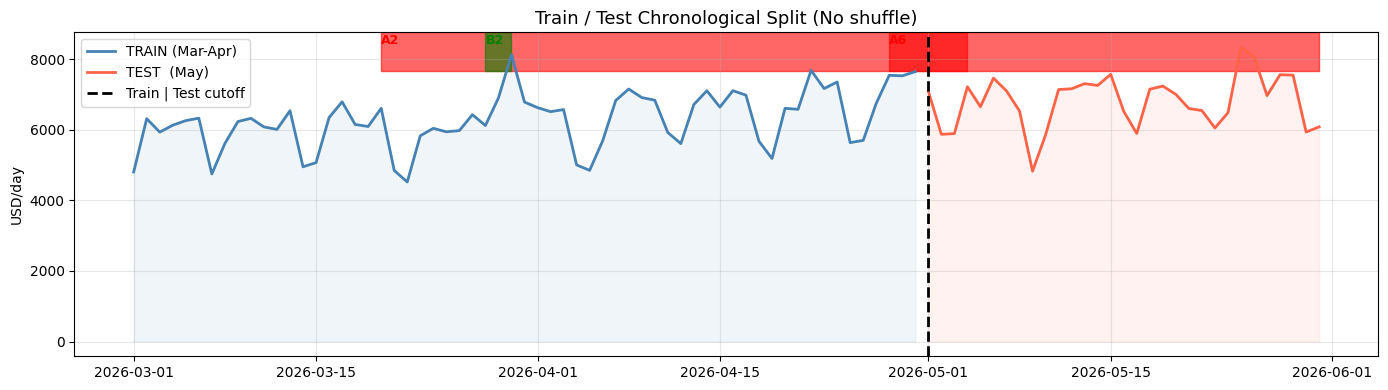

Train days: 61 | Train cost: $382,887
Test days:  31  | Test cost:  $210,887


In [21]:
## 18. Dataset Quality Check — Balance, Coverage & Train/Test Split Strategy

print('=== Class Balance — metrics_haikhoa (supervised candidates) ===')
for name, df in metrics_info.items():
    counts   = df['label'].value_counts()
    normal_n = counts.get('normal',  0)
    anom_n   = counts.get('anomaly', 0)
    benign_n = counts.get('benign',  0)
    ratio    = anom_n / (normal_n + 1e-9)
    warn     = '⚠️  IMBALANCED' if ratio < 0.15 else '✓ OK'
    print(f'{name:15s}: normal={normal_n:5d} | anomaly={anom_n:4d} | benign={benign_n:3d} | ratio={ratio:.3f} {warn}')

print()
print('=== Cost Data (CUR/CE) — Why NOT supervised? ===')
print('Total days: 92 | Only 3 public labels (2 anomaly + 1 benign)')
print('→ Cannot train supervised classifier on CUR/CE directly — insufficient labels')
print('→ Use UNSUPERVISED on CUR/CE, calibrate threshold with public labels')
print('→ SEMI-SUPERVISED: train on metrics (has labels), transfer features to CUR')

print()
print('=== Time Series Train/Test Split — Chronological (NO shuffle) ===')
TRAIN_END  = pd.Timestamp('2026-04-30')
TEST_START = pd.Timestamp('2026-05-01')

print(f'TRAIN: 2026-03-01 → 2026-04-30 (61 days, ~66%)')
print(f'TEST:  2026-05-01 → 2026-05-31 (31 days, ~34%)')
print(f'Rationale:')
print(f'  - 2-month train gives 14d rolling baseline for EVERY (account x service) pair')
print(f'  - Test window (May) contains A6 end window + likely other anomalies')
print(f'  - Shuffle = data leakage for time series — forbidden')
print(f'  - Walk-forward validation possible in W12 if time permits')

# Visualize split
TRAIN_END  = pd.Timestamp('2026-04-30', tz='UTC')
TEST_START = pd.Timestamp('2026-05-01', tz='UTC')

fig, ax = plt.subplots(figsize=(14, 4))
train_m  = daily_total['date'] <= TRAIN_END
test_m   = daily_total['date'] >= TEST_START
ax.plot(daily_total[train_m].date,  daily_total[train_m].cost,  color='steelblue', lw=2, label='TRAIN (Mar-Apr)')
ax.plot(daily_total[test_m].date,   daily_total[test_m].cost,   color='tomato',    lw=2, label='TEST  (May)')
ax.axvline(TEST_START, color='black', lw=2, ls='--', label='Train | Test cutoff')
ax.fill_between(daily_total[train_m].date, 0, daily_total[train_m].cost, alpha=0.08, color='steelblue')
ax.fill_between(daily_total[test_m].date,  0, daily_total[test_m].cost,  alpha=0.08, color='tomato')
for _, row in labels.iterrows():
    c = 'red' if row['label'] == 'anomaly' else 'green'
    ax.axvspan(row['start_date'], row['end_date'], ymin=0.88, ymax=1.0, color=c, alpha=0.6)
    ax.text(row['start_date'], daily_total.cost.max()*1.01, row['anomaly_id'],
            fontsize=9, color=c, fontweight='bold')
ax.set_title('Train / Test Chronological Split (No shuffle)', fontsize=13)
ax.set_ylabel('USD/day')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Train days: {train_m.sum()} | Train cost: ${daily_total[train_m].cost.sum():,.0f}')
print(f'Test days:  {test_m.sum()}  | Test cost:  ${daily_total[test_m].cost.sum():,.0f}')

## 19. EDA Summary & Model Selection Rationale

### 1. Dataset Characteristics
- 92 days · 6 accounts · 17 services · 276 resources · **$593k total spend**
- Organic growth trend +13% Mar→May (not anomalous)
- Clear weekday/weekend seasonality: ~25-30% drop on weekends
- Anomaly rate: ~6.9% of total cost (from public label sample)
- Metrics data: 3-class labels (normal/anomaly/benign) — valuable for semi-supervised

### 2. Key Detection Signals Found in EDA

| Anomaly Type | Signal | Data Source |
|---|---|---|
| `sudden_spike` | z-score > 3 on (account × service) | CUR/CE daily |
| `idle_resource` | flat cost, very low CV (<0.15), long active_days, db_connections ~0 | CUR + RDS metrics |
| `runaway_usage` | high weekend_ratio (≥0.9), flat hourly CPU 24/7, new resource | CUR + EC2/SM metrics |
| `untagged_spend` | `resource_tags_user_team` null, cost > threshold | CUR only |
| `gradual_drift` | positive linear slope 14d, decorrelation vs peer series | CUR/CE |
| `benign (FP trap)` | same z-score as spike BUT short duration + returns to baseline | CUR + context |

### 3. Imbalance & Data Quality Summary
- CUR: only 3 public labels → **cannot train supervised** directly
- Metrics: 9-15% anomaly rate → moderately imbalanced, use `class_weight='balanced'` or SMOTE
- `is_estimated=True` on last 2 days only → handle at inference time
- `resource_tags_user_owner` 99.6% null — by design (not a data quality issue)

### 4. Recommended Model Architecture — 2-Layer Strategy

```
LAYER 1 — Rule-based detectors (fast, interpretable, per anomaly type)
  • z-score threshold (>3)    → sudden_spike
  • weekend ratio rule (≥0.9) → runaway_usage  
  • hourly_std < threshold    → flat profile = runaway / idle
  • null-tag filter           → untagged_spend (deterministic)
  • CV + active_days          → idle_resource
  • trend slope 14d           → gradual_drift

LAYER 2 — ML confidence scoring (unsupervised + semi-supervised)
  • Isolation Forest   → global anomaly score on engineered feature vector
  • XGBoost (semi-sup) → train on metrics_haikhoa labels → infer on CUR features  
  • LOF               → cluster-based outlier on (account, service) daily cost vectors

FINAL SCORE = max(Layer1_trigger) × Layer2_confidence_score
THRESHOLD   = calibrated on public labels (A2, A6 fire; B2 does NOT fire)
TARGET      = Precision ≥80%, FP ≤10%
```

### 5. Time Frame Decision: **24h cadence**
- **12h**: insufficient data points for rolling baseline per series; AWS CUR is daily grain
- **24h**: natural CUR grain; aligns with weekday/weekend seasonality; supports 14d rolling window  
- **48h**: too slow for runaway GPU ($400/day → $800 lost per detection cycle)
- **ADR decision**: 24h balances FP risk vs detection speed for this specific cost cadence

---
*Next step: `hao-aiops/engine/capstone_project.ipynb` — Feature Engineering → Model Training → Evaluation*